In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
with open('TST_Extracted_Features.p','rb') as f:
    myDict = pickle.load(f)

with open('PowerSocialData.p','rb') as f:
    myDict2 = pickle.load(f)

In [3]:
def select_train_indices(y_mouse_tst, n_train, seed=42):
    """
    Select indices belonging to a random subset of n_train unique values in y_mouse_tst.

    Parameters
    ----------
    y_mouse_tst : array-like
        Input vector of labels or values.
    n_train : int
        Number of unique values to select.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    mask : np.ndarray, dtype=bool
        Boolean vector of length len(y_mouse_tst) with True for selected indices.
    """
    y = np.asarray(y_mouse_tst)
    unique_vals = np.unique(y)

    if n_train > len(unique_vals):
        raise ValueError("n_train exceeds number of unique values in y_mouse_tst.")

    rng = np.random.default_rng(seed)
    selected_vals = rng.choice(unique_vals, size=n_train, replace=False)

    mask = np.isin(y, selected_vals)

    return mask


def filter_bottom_1pct(X, y, z, model_pca):
    """
    Compute PCA-based density scores and remove the bottom 1 percent.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input matrix.
    y : array-like, shape (n_samples,)
        Associated vector of labels or values.
    z : array-like, shape (n_samples,)
        Second associated vector of labels or values.
    model_pca : object
        A fitted model with a score_samples method.

    Returns
    -------
    scores_filt : np.ndarray
        Filtered score_samples output.
    y_filt : np.ndarray
        y with bottom 1 percent removed.
    z_filt : np.ndarray
        z with bottom 1 percent removed.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    z = np.asarray(z)

    # Compute PCA density scores
    scores_test = model_pca.score_samples(X)

    # Determine threshold for bottom 1 percent
    thresh = np.percentile(scores_test, .1)

    # Mask for keeping samples above the threshold
    mask = scores_test > thresh

    # Apply mask
    scores_filt = scores_test[mask]
    y_filt = y[mask]
    z_filt = z[mask]

    return scores_filt, y_filt, z_filt


In [4]:
y_task_tst = myDict['task']
y_mouse_tst = myDict['mouse']
y_mouse_soc = myDict2['y_mouse']
y_task_soc = myDict2['y_social']

In [5]:
X1 = myDict['power']
#XX1 = StandardScaler().fit_transform(X1)


In [6]:
X1p = np.log(X1[:10000])

In [7]:
X2p = np.log(X1[1*10000:2*10000])
X3p = np.log(X1[2*10000:3*10000])
X4p = np.log(X1[3*10000:4*10000])
X5p = np.log(X1[4*10000:5*10000])
X6p = np.log(X1[5*10000:])

In [8]:
X1l = np.vstack((X1p,X2p,X3p,X4p,X5p,X6p))

In [9]:
X2 = myDict2['X_psd']
Xllist = []
for i in range(13):
    Xllist.append(np.log(X2[i*10000:(i+1)*10000]))
Xllist.append(np.log(X2[130000:]))

In [10]:
X2l = np.vstack(Xllist)

In [11]:
XX1 = StandardScaler().fit_transform(X1l)
XX2 = StandardScaler().fit_transform(X2l)

In [12]:
power_list_tst = {}
idx = 2
power_list_tst['Amy'] = XX1[:,idx*56:(idx+1)*56]

power_list_tst['NAc'] = (XX1[:,0*56:(0+1)*56] + XX1[:,1*56:(1+1)*56])/2

idx = 4
power_list_tst['MD_Thal'] = XX1[:,idx*56:(idx+1)*56]

idx = 3
power_list_tst['IL'] = XX1[:,idx*56:(idx+1)*56]

idx = 5
power_list_tst['PrL'] = XX1[:,idx*56:(idx+1)*56]

idx = 6
power_list_tst['VTA'] = XX1[:,idx*56:(idx+1)*56]

idx = 7
power_list_tst['Hip'] = (XX1[:,idx*56:(idx+1)*56] + XX1[:,9*56:(9+1)*56])/2

In [13]:
power_list_social = {}
idx = 0
power_list_social['Amy'] = XX2[:,idx*56:(idx+1)*56]
idx = 1
power_list_social['Cg'] = XX2[:,idx*56:(idx+1)*56]
idx = 2
power_list_social['IL'] = XX2[:,idx*56:(idx+1)*56]
idx = 3
power_list_social['PrL'] = XX2[:,idx*56:(idx+1)*56]
idx = 4
power_list_social['NAc'] = XX2[:,idx*56:(idx+1)*56]
idx = 5
power_list_social['Hip'] = XX2[:,idx*56:(idx+1)*56]
idx = 6
power_list_social['MD_Thal'] = XX2[:,idx*56:(idx+1)*56]
idx = 7
power_list_social['VTA'] = XX2[:,idx*56:(idx+1)*56]

## Common are Amy, NAc, MD_Thal, IL, PrL, Hip, VTA

In [14]:
rd = power_list_social
X_social = np.hstack((rd['Amy'],rd['NAc'],rd['MD_Thal'],rd['IL'],rd['PrL'],rd['Hip'],rd['VTA']))
rd = power_list_tst
X_tst = np.hstack((rd['Amy'],rd['NAc'],rd['MD_Thal'],rd['IL'],rd['PrL'],rd['Hip'],rd['VTA']))

In [ ]:
def analysis(X_social,y_mouse_soc,y_task_soc,X_tst,y_mouse_tst,y_task_tst,n_train,seed):
    idx_train = select_train_indices(y_mouse_soc, n_train, seed=42)
    results = {}
    model_pca = PCA(20)
    model_pca.fit(X_social[idx_train])
    results['

In [15]:
idx_train = select_train_indices(y_mouse_soc, n_train, seed=42)
model_pca = PCA(20)
model_pca.fit(X_social[idx_train])

,n_components,20
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
scores_filt, mouse_s_filt, task_s_filt = filter_bottom_1pct(X_social[idx_train==False],
                                                 y_mouse_soc[idx_train==False],
                                                 y_task_soc[idx_train==False],
                                                           model_pca)

In [28]:
savg_soc = np.array([np.mean(scores_filt[mouse_s_filt==m]) for m in np.unique(mouse_s_filt)])
savg_soc

array([-328.67484, -337.4498 , -365.41736, -409.75586, -329.7746 ,
       -330.44373, -348.11377, -319.37863, -324.49048, -338.61685,
       -351.4033 , -339.60757, -310.76007], dtype=float32)

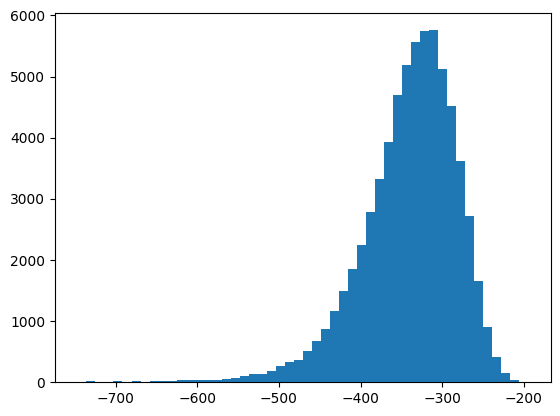

In [17]:
plt.hist(scores_filt,50);

In [18]:
scores_tst_filt, mouse_t_filt, task_t_filt = filter_bottom_1pct(X_tst,
                                                 y_mouse_tst,
                                                 y_task_tst,
                                                           model_pca)

In [29]:
savg_tst = np.array([np.mean(scores_tst_filt[mouse_t_filt==m]) for m in np.unique(mouse_t_filt)])
savg_tst

array([-382.74203, -385.56772, -422.6849 , -407.39044, -442.339  ,
       -386.63098, -432.1708 , -436.36432, -405.50436, -422.95978,
       -413.48334, -434.27774, -392.9396 , -439.22955, -418.27408,
       -393.5724 , -395.4618 , -427.76218, -426.47626, -428.5139 ,
       -401.60413, -405.37842, -373.30136, -401.00418, -421.20312,
       -397.5932 ], dtype=float32)

In [40]:
import numpy as np

def mean_scores_by_mouse_and_task(mouse_t_filt, scores_tst_filt, task_t_filt):
    """
    Returns an array of shape (n_unique_mice, 2), where:
      result[i, 0] = mean score for mouse i with task == 0
      result[i, 1] = mean score for mouse i with task == 1
    """
    mice = np.unique(mouse_t_filt)
    tasks = np.array([0, 1])

    # Masks for mouse and task membership
    mouse_mask = mouse_t_filt[:, None] == mice[None, :]      # (N, M)
    task_mask  = task_t_filt[:, None]  == tasks[None, :]     # (N, 2)

    # Combine into (N, M, 2)
    combined_mask = mouse_mask[:, :, None] & task_mask[:, None, :]

    # Weighted sums and counts
    num   = np.sum(scores_tst_filt[:, None, None] * combined_mask, axis=0)  # (M, 2)
    denom = np.sum(combined_mask, axis=0)                                   # (M, 2)

    return num / denom


In [41]:
savg_tst_mat = mean_scores_by_mouse_and_task(mouse_t_filt, scores_tst_filt, task_t_filt)

In [42]:
savg_soc_mat = mean_scores_by_mouse_and_task(mouse_s_filt, scores_filt, task_s_filt)


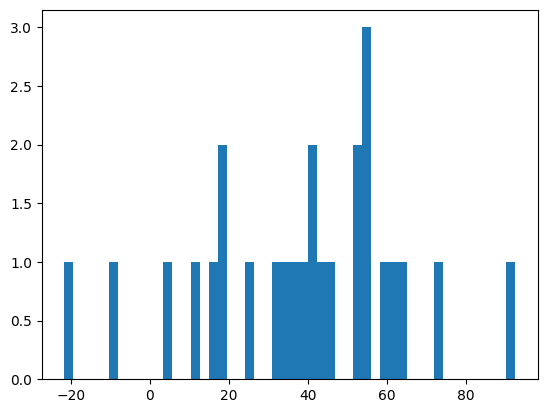

In [48]:
plt.hist(savg_tst_mat[:,0]-savg_tst_mat[:,1],bins=50);

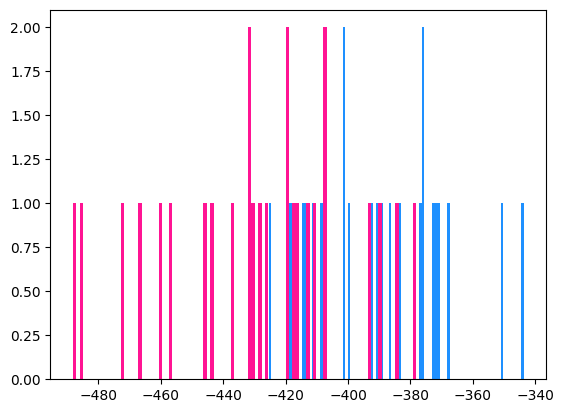

In [53]:
plt.hist(savg_tst_mat[:,0],color='dodgerblue',bins=100);
plt.hist(savg_tst_mat[:,1],color='deeppink',bins=100);


In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

def _silverman_bandwidth(x):
    """Silverman's rule-of-thumb bandwidth for 1D data."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = x.size
    if n < 2:
        return 1.0  # fallback
    std = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(std, iqr / 1.34) if iqr > 0 else std
    if sigma == 0:
        sigma = 1.0
    return 0.9 * sigma * n ** (-1.0 / 5.0)


def plot_kde_four(v1, v2, v3, v4, labels=None):
    """
    Plot KDEs for four 1D vectors v1..v4 using a compact-support kernel
    (Epanechnikov) with bandwidth inferred via Silverman's rule.

    Parameters
    ----------
    v1, v2, v3, v4 : array-like
        Input 1D vectors.
    labels : list of str or None
        Optional labels for legend (len(labels) == 4).
    """
    vectors = [np.asarray(v) for v in (v1, v2, v3, v4)]

    # Flatten and drop NaNs
    vectors = [v[np.isfinite(v)] for v in vectors]

    # Build a common grid over all data
    all_vals = np.concatenate(vectors)
    data_min, data_max = np.min(all_vals), np.max(all_vals)
    margin = 0.05 * (data_max - data_min if data_max > data_min else 1.0)
    xs = np.linspace(data_min - margin, data_max + margin, 400)[:, None]

    # Pastel color palette
    colors = [
        "#a6cee3",  # light blue
        "#b2df8a",  # light green
        "#fdbf6f",  # light orange
        "#cab2d6",  # light purple
    ]

    if labels is None:
        labels = ["v1", "v2", "v3", "v4"]

    # Create figure
    fig, ax = plt.subplots(figsize=(7, 4))

    for v, color, label in zip(vectors, colors, labels):
        if v.size == 0:
            continue

        # Epanechnikov kernel has compact support
        h = _silverman_bandwidth(v)
        kde = KernelDensity(kernel="gaussian", bandwidth=h)
        kde.fit(v[:, None])

        log_dens = kde.score_samples(xs)
        dens = np.exp(log_dens)

        ax.plot(xs[:, 0], dens, label=label, linewidth=2.2, alpha=0.9, color=color)

    # Styling: no "shitty" grid, just clean axes
    ax.grid(False)

    # Remove top and right spines, thicken bottom and left
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)

    # Larger labels and title
    ax.set_xlabel("Likelihood", fontsize=20)
    ax.set_ylabel("Density", fontsize=20)
    ax.set_title('Electrophysiology Likelihood Distribution',fontsize=24)
    ax.tick_params(axis="both", which="major", labelsize=12)

    ax.legend(frameon=False, fontsize=12)
    
    fig.tight_layout()
    return fig, ax


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Electrophysiology Likelihood Distribution'}, xlabel='Likelihood', ylabel='Density'>)

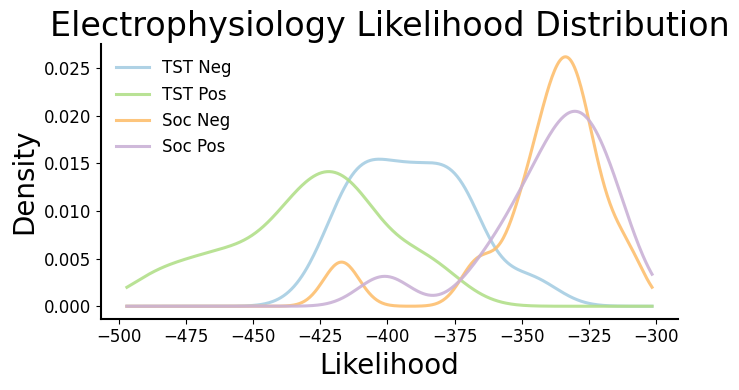

In [66]:
plot_kde_four(savg_tst_mat[:,0], savg_tst_mat[:,1], 
              savg_soc_mat[:,0], savg_soc_mat[:,1],
              labels=['TST Neg','TST Pos','Soc Neg','Soc Pos'])

In [82]:
print(np.median(savg_tst_mat[:,0]),np.std(savg_tst_mat[:,0]))
print(np.median(savg_tst_mat[:,1]),np.std(savg_tst_mat[:,1]))
print(np.median(savg_soc_mat[:,0]),np.std(savg_soc_mat[:,0]))
print(np.median(savg_soc_mat[:,1]),np.std(savg_soc_mat[:,1]))




-391.7968433861346 20.599243372762484
-427.00039806356153 28.864747566687143
-337.42112926136366 25.596254303810117
-335.90995716168715 22.708505237956135


In [67]:
from batchdetect.loader import *
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt


In [68]:
def null_factory() -> HeavyMixture:
    return HeavyMixture(
        n_components=1,
        component_distribution='gennorm',
        n_init=3,
        max_iter=1000,
    )

def alt_factory() -> HeavyMixture:
    return HeavyMixture(
        n_components=2,
        component_distribution='gennorm',
        n_init=3,
        max_iter=1000,
    )

In [74]:
savg_tot_tst = np.concatenate((savg_tst_mat[:,0],savg_tst_mat[:,1]))
res_tst = parametric_bootstrap_lrt(savg_tot_tst,null_factory,alt_factory,1000,random_state=2021)

In [76]:
res_tst['p_value']

np.float64(0.6893106893106893)

In [75]:
savg_soc_soc = np.concatenate((savg_soc_mat[:,0],savg_soc_mat[:,1]))
res_soc = parametric_bootstrap_lrt(savg_soc_soc,null_factory,alt_factory,1000,random_state=2021)

In [77]:
res_soc['p_value']

np.float64(0.053946053946053944)

In [79]:
savg_tot_tot = np.concatenate((savg_soc_soc,savg_tot_tst))
res_tot = parametric_bootstrap_lrt(savg_tot_tot,null_factory,alt_factory,1000,random_state=2021)

In [80]:
res_tot['p_value']

np.float64(0.004995004995004995)

In [83]:
len(np.unique(y_mouse_soc))

28

In [84]:
len(np.unique(y_mouse_tst))

26

54